In [68]:
import pandas as pd
from scipy import stats
from tqdm import tqdm
import numpy as np
import math as mt
from scipy.stats import norm
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import math
import pickle
import warnings
warnings.filterwarnings("ignore")

# Import final preprocessed data

In [69]:
final_anonimized_df = "thesis_data/final_anonimous_dataset.xlsx"
sequential_anonimized_df = "thesis_data/final_anonimous_sequential_dataset.xlsx"
final_anonimized_df_SCS = "thesis_data/final_anonimous_SCS_dataset.xlsx"
grouped_df = "thesis_data/grouped_df.xlsx"
distribution_df = "thesis_data/distribution_df.xlsx"


In [70]:
final_grouped_df = pd.read_excel(final_anonimized_df)
sequential_final_df = pd.read_excel(sequential_anonimized_df)
final_grouped_SCS_df = pd.read_excel(final_anonimized_df_SCS)
grouped_df = pd.read_excel(grouped_df)
distribution_df = pd.read_excel(distribution_df)

# Theory functions

In [71]:

def simulate_ab_test_bayes(conversions_a, users_a, conversions_b, users_b, simulations=100000, prior_alpha=1, prior_beta=1):
    """
    Calculates joint posterior distribution of two beta distributions,
    calculates expected loss based on the loss function.
    """

    conversion_rate_a = np.random.beta(conversions_a + prior_alpha, users_a - conversions_a + prior_beta, simulations)
    conversion_rate_b = np.random.beta(conversions_b + prior_alpha, users_b - conversions_b + prior_beta, simulations)

    b_better_than_a = (conversion_rate_b > conversion_rate_a).mean()
    loss_a = np.mean((conversion_rate_a < conversion_rate_b) * (conversion_rate_b - conversion_rate_a))
    loss_b = np.mean((conversion_rate_a > conversion_rate_b) * (conversion_rate_a - conversion_rate_b))

    return {
        'conversion_rate_a_samples': conversion_rate_a,
        'conversion_rate_b_samples': conversion_rate_b,
        'p_b_better_than_a': b_better_than_a,
        'expected_loss_a': loss_a,
        'expected_loss_b': loss_b
    }

def calculate_confidence_interval(data, confidence=0.95):
    """
    Calculates a confidence interval for a given dataset.
    Returns the lower and upper bounds based on the specified confidence level
    (default 95%).

    """
    lower_percentile = ((1.0 - confidence) / 2.0) * 100
    upper_percentile = (1.0 - (1.0 - confidence) / 2.0) * 100
    lower_bound = np.percentile(data, lower_percentile)
    upper_bound = np.percentile(data, upper_percentile)
    return lower_bound, upper_bound

def compute_p_value_two_tailed(conversions_a, users_a, conversions_b, users_b):
    """
    Computes a two-tailed p-value for two proportions.
    Uses a z-test to evaluate if the difference in conversion rates between two
    groups is statistically significant.

    """
    cr_a = conversions_a / users_a
    cr_b = conversions_b / users_b
    pooled_cr = (conversions_a + conversions_b) / (users_a + users_b)
    s_error = np.sqrt(pooled_cr * (1 - pooled_cr) * (1/users_a + 1/users_b))
    z_score = (cr_b - cr_a) / s_error
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    return p_value
def simulate_cr(conversions_a, users_a, conversions_b, users_b,  simulations=500):
    """
    Simulates A/B test conversion data over time.
    Generates multiple simulation runs of user conversions based on binomial distributions,
    grouping observations by checkpoints
    """
    np.random.seed(33)
    obs_increments = 5000
    max_obs = 100000
    checkins = np.arange(obs_increments, max_obs + 1, obs_increments)
    all_experiments = []
    a_cvr = conversions_a/users_a
    b_cvr = conversions_b/users_b
    for sim in tqdm(range(1, simulations + 1), desc="running bayes sims"):
      a_obs = np.random.binomial(1, a_cvr, max_obs)
      b_obs = np.random.binomial(1, b_cvr, max_obs)
      df = pd.DataFrame({
            'n_sim': sim,
            'time': np.arange(1, max_obs + 1),
            'a_obs': a_obs,
            'b_obs': b_obs
        })
      df['checkin'] = np.ceil(df['time'] / obs_increments) * obs_increments
      grouped = df.groupby(['n_sim', 'checkin']).agg({
          'a_obs': 'sum',
          'b_obs': 'sum'
      }).reset_index()
      grouped = grouped.sort_values('checkin')
      grouped['a_conv'] = grouped.groupby('n_sim')['a_obs'].cumsum()
      grouped['b_conv'] = grouped.groupby('n_sim')['b_obs'].cumsum()
      all_experiments.append(grouped)

    experiment_record = pd.concat(all_experiments, ignore_index=True)
    return experiment_record
def get_loss(sims, post_samples=10000, prior_alpha=1, prior_beta=1):
    """
    Estimates Bayesian loss for two variants across simulations.
    Draws posterior samples using Beta distributions and computes expected loss
    for choosing each variant at different checkpoints.
    """

    a_conv = sims['a_conv'].to_numpy()
    b_conv = sims['b_conv'].to_numpy()
    checkin = sims['checkin'].to_numpy()

    n = len(sims)

    a_alpha = prior_alpha + a_conv[:, None]
    a_beta = prior_beta + (checkin - a_conv)[:, None]
    b_alpha = prior_alpha + b_conv[:, None]
    b_beta = prior_beta + (checkin - b_conv)[:, None]

    a_post = np.random.beta(a_alpha, a_beta, size=(len(sims), post_samples))
    b_post = np.random.beta(b_alpha, b_beta, size=(len(sims), post_samples))

    loss_a = np.mean((a_post < b_post) * (b_post - a_post), axis=1)
    loss_b = np.mean((a_post > b_post) * (a_post - b_post), axis=1)

    sims = sims.copy()
    sims['loss_a'] = loss_a
    sims['loss_b'] = loss_b
    return sims

def compute_chi2_p_value(conversions_a, users_a, conversions_b, users_b):
    """
    Computes a Chi-squared test p-value for two groups.
    """
    contingency = np.array([
        [conversions_a, users_a - conversions_a],
        [conversions_b, users_b - conversions_b]
    ])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency, correction=False)
    return p_value
def interpret_ab_test_with_mde(conversions_a, users_a, conversions_b, users_b, alpha=0.05, mde=0.1):
    """
    Interprets A/B test results based on statistical significance and minimum detectable effect (MDE).
    Returns whether "Test", "Control", or "No stat Diff" based on the p-value,
    effect size, and comparison to MDE threshold.
    """
    p = compute_chi2_p_value(conversions_a, users_a, conversions_b, users_b)
    cr_a = conversions_a / users_a
    cr_b = conversions_b / users_b
    effect = cr_b/cr_a-1

    if p < alpha:
        if abs(effect) >= mde and effect>=0:
            return "Test", p, effect
        elif abs(effect) >= mde and effect<=0:
            return "Control", p, effect
        else:
            return "No stat Diff", p, effect
    else:
        return "No stat Diff", p, effect

In [72]:
def get_z_score(alpha):
    """
    Returns the z-score corresponding to a given cumulative probability (alpha).
    """
    return norm.ppf(alpha)

def get_sds(p,d):
    """
    Calculates the standard deviations needed for sample size estimation.
    Given a baseline conversion rate p and a minimum detectable effect d,
    returns a list containing two standard deviations(baseline and with expected change)
    """
    sd1=mt.sqrt(2*p*(1-p))
    sd2=mt.sqrt(p*(1-p)+(p
    )*(1-(p+d)))
    sds=[sd1,sd2]
    return sds

def get_sampSize(sds,alpha,beta,d):
    """
    Computes the minimum required sample size per group for an A/B test.
    Uses the standard deviations (sds), significance level (alpha),
    statistical power (1 - beta), and minimum detectable difference (d) to calculate the needed sample size.
    """
    n=pow((get_z_score(1-alpha/2)*sds[0]+get_z_score(1-beta)*sds[1]),2)/pow(d,2)
    return n

# Compute frequentist stats and add to dataframes

In [73]:
multivariable_tests_map = {"2024_08_03_experiment_5":"T2",\
                           "2024_08_06_experiment_6":"T1",\
                           "2024_08_07_experiment_7":"T4",\
                           "2024_10_10_experiment_19":"T2",\
                           "2024_10_11_experiment_20":"T1",\
                           "2024_11_07_experiment_25":"T3"
                           }

In [74]:

def compute_frequentist_stats(final_grouped_df):
  """
  Generates frequentist A/B test statistics for each experiment.

  Iterates through experiments in the provided DataFrame and computes:
  - Conversion rates for control and test groups,
  - Test result classification ("Test", "Control", "No stat Diff"),
  - Required sample size for significance based on MDE,
  - Whether the actual sample size was sufficient.

  Returns:
      dict: Experiment results keyed by experiment ID.
  """
  tests = final_grouped_df['experiment_id'].unique()
  experiment_results_dct = {}

  for test in tests:
      if test =='2024_10_21_experiment_22':
        continue
      baseline = final_grouped_df[(final_grouped_df["experiment_id"] == test) &
                                  (final_grouped_df["variation"] == "C")]
      if baseline.empty:
          continue
      if test in multivariable_tests_map:
        test1 = final_grouped_df[(final_grouped_df["experiment_id"] == test) &
                                (final_grouped_df["variation"] == multivariable_tests_map[test])]

      else:
        test1 = final_grouped_df[(final_grouped_df["experiment_id"] == test) &
                                ((final_grouped_df["variation"] == "T")|(final_grouped_df["variation"] == "T1"))]
      if test1.empty:
        continue

      experiment_results_dct[test] = {}
      p = float(baseline["conversion_rate"].iloc[0])
      real_sample = float(baseline["first_screen_view"].iloc[0])
      experiment_results_dct[test]["Result_prev"] = baseline["Result_x"].iloc[0]
      experiment_results_dct[test]["Owner"] = baseline["Test Owner"].iloc[0]

      users_a, conversions_a = baseline["CR_1"].iloc[0], baseline["CR_2"].iloc[0]
      users_b, conversions_b = test1["CR_1"].iloc[0], test1["CR_2"].iloc[0]

      d_min= p * 0.1
      experiment_results_dct[test]["funnel"] = baseline["funnel"]
      experiment_results_dct[test]["conversion_rate"] = p
      experiment_results_dct[test]["real_sample"] = real_sample
      experiment_results_dct[test]["C_users"] = users_a
      experiment_results_dct[test]["C_conversions"] = conversions_a

      experiment_results_dct[test]["CR_1"] = conversions_a/users_a
      experiment_results_dct[test]["CR_2"] = conversions_b/users_b

      experiment_results_dct[test]["T_users"] = users_b
      experiment_results_dct[test]["T_conversions"] = conversions_b
      experiment_results_dct[test]["Result_our"] = {"result":interpret_ab_test_with_mde(conversions_a, users_a, conversions_b, users_b, alpha=0.05, mde=0.1)[0],\
                                                    "p":interpret_ab_test_with_mde(conversions_a, users_a, conversions_b, users_b, alpha=0.05, mde=0.1)[1],\
                                                    "effect":interpret_ab_test_with_mde(conversions_a, users_a, conversions_b, users_b, alpha=0.05, mde=0.1)[2]}
      experiment_results_dct[test]["SampSize"] = round(
          get_sampSize(get_sds(p, d_min), 0.1, 0.2, d_min)
      )
      experiment_results_dct[test]["Significant"] = True if real_sample>= experiment_results_dct[test]["SampSize"] else False
  return experiment_results_dct



In [75]:
experiment_results_dct_psv = compute_frequentist_stats(final_grouped_df)

In [76]:
names_true_sample = {exp: [data.get('SampSize'),data.get('Significant')] for exp, data in experiment_results_dct_psv.items()}

In [77]:
result_counts = {}
significant_counts = {}
owner_counts={}
owner_sign ={}
for exp, data in experiment_results_dct_psv.items():
    # print(data)
    if not data or 'Result_prev' not in data:
        print(f"Skipping empty or invalid entry for experiment: {exp}")
        continue
    result = data['Result_prev']
    owner =data['Owner']
    significant = data['Significant']
    result_counts[result] = result_counts.get(result, 0) + 1
    owner_counts[owner] = owner_counts.get(owner, 0) + 1
    if significant:
       significant_counts[result] = significant_counts.get(result, 0) + 1
       owner_sign[owner] = owner_sign.get(owner, 0) + 1

result_percentages = {
    result: ((significant_counts.get(result, 0) / result_counts[result]) * 100, significant_counts.get(result, 0), result_counts[result])
    for result in result_counts
}

owner_percentages = {
    owner: ((owner_sign.get(owner, 0) / owner_counts[owner]) * 100, owner_sign.get(owner, 0), owner_counts[owner])
    for owner in owner_counts
}
for result, percentage in result_percentages.items():
    print(f"{result}: {percentage[0]:.2f}% of tests were significant, {percentage[1]}/{percentage[2]}")

print('\n')
for owner, percentage in owner_percentages.items():
    print(f"{owner}: {percentage[0]:.2f}% of tests were significant, {percentage[1]}/{percentage[2]}")

No Stat Diff: 68.75% of tests were significant, 11/16
Control: 38.46% of tests were significant, 5/13
Test: 70.83% of tests were significant, 17/24


MS: 56.52% of tests were significant, 13/23
IK: 50.00% of tests were significant, 5/10
IK/MK/RM: 100.00% of tests were significant, 1/1
IK/VP: 0.00% of tests were significant, 0/1
VP: 77.78% of tests were significant, 14/18


In [78]:
experiment_results_dct_psv_sign = {
    k: v for k, v in experiment_results_dct_psv.items() if v.get('Significant') is True
}

In [79]:
experiment_results_dct_psv_mixed = {
    k: v for k, v in experiment_results_dct_psv.items()
    if (v.get('Result_prev') == 'Test' and v.get('Significant') is True) or (v.get('Result_prev') != 'Test')
}


# Distribution estimation and traffic visualizations

In [80]:
test_counts = final_grouped_df[['experiment_id', 'funnel']].drop_duplicates().funnel.value_counts()
print(test_counts)


funnel
Funnel_B    25
Funnel_A    21
Funnel_T     6
Funnel_Q     2
Name: count, dtype: int64


In [81]:
test_counts = final_grouped_df[['experiment_id', "test_duration"]].drop_duplicates().test_duration.value_counts()
print(test_counts)


test_duration
4     9
3     8
5     7
2     7
1     4
0     4
6     4
8     3
7     2
13    2
9     1
10    1
11    1
15    1
Name: count, dtype: int64


In [82]:
distribution_df = distribution_df.groupby(
    ['siteDomain', 'yyyymmdd'],
    sort=False
)[
    ['first_screen_view', 'email_enter_success', 'payment_screen_view',
     'sale_confirmation_success', 'total_count']
].sum().reset_index()

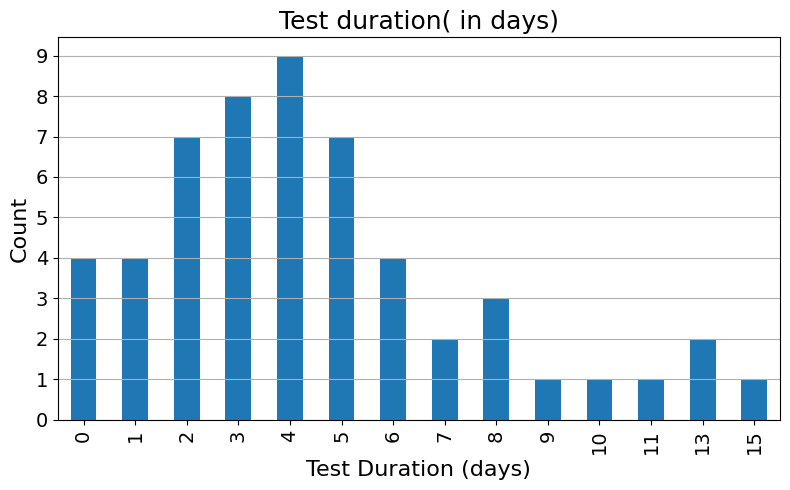

In [83]:

plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20
})

plt.figure(figsize=(8, 5))
test_counts.sort_index().plot(kind='bar')
plt.xlabel("Test Duration (days)")
plt.yticks(range(0, int(test_counts.max()) + 1))
plt.ylabel("Count")
plt.title('Test duration( in days)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [84]:
distribution_df["Cr_email"] = distribution_df["email_enter_success"]/distribution_df["first_screen_view"]
distribution_df["Cr_payment"] = distribution_df["payment_screen_view"]/distribution_df["first_screen_view"]
distribution_df["Cr_sale_confirmation_success"] = distribution_df["sale_confirmation_success"]/distribution_df["first_screen_view"]

In [85]:
beauty_df = distribution_df[distribution_df['siteDomain'] == 'lumi.mybeautybox.style']
beauty_df = beauty_df.sort_values('yyyymmdd')
beauty_df['month'] = beauty_df['yyyymmdd'].dt.month

In [86]:
distribution_df = distribution_df.sort_values('yyyymmdd')
distribution_df['month'] = distribution_df['yyyymmdd'].dt.month

In [87]:
monthly_sum_beauty = beauty_df.groupby('month')['first_screen_view'].sum().reset_index()

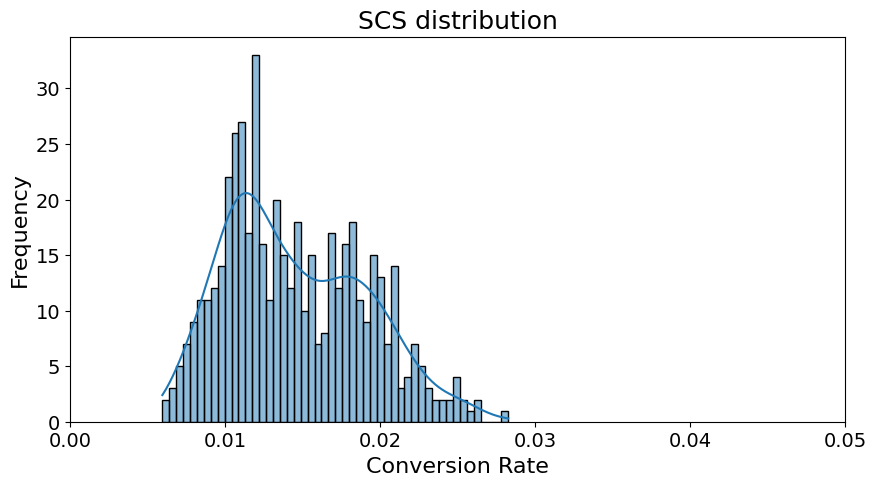

In [88]:

plt.figure(figsize=(10, 5))
sns.histplot(distribution_df['Cr_sale_confirmation_success'], bins=50, kde=True)
plt.xlabel('Conversion Rate')
plt.xlim(0, 0.05)
plt.ylabel('Frequency')
plt.title('SCS distribution')
plt.show()

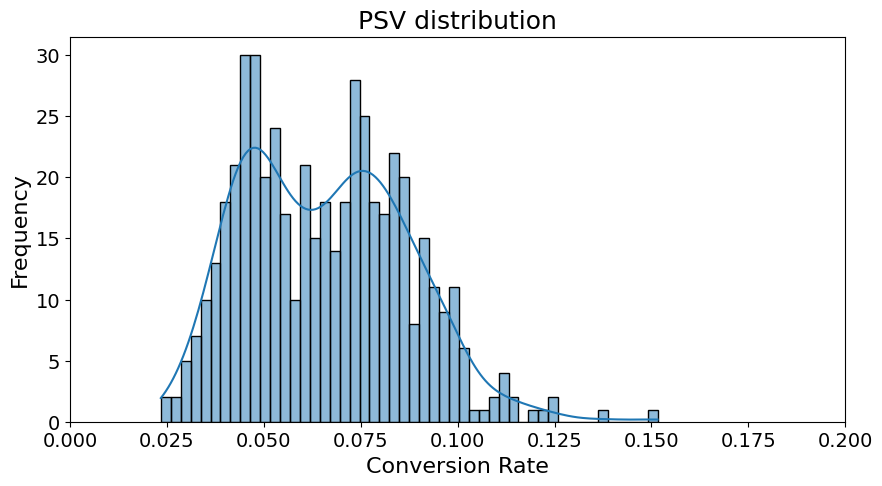

In [89]:


plt.figure(figsize=(10, 5))
sns.histplot(distribution_df['Cr_payment'], bins=50, kde=True)
plt.xlabel('Conversion Rate')
plt.xlim(0, 0.2)
plt.ylabel('Frequency')
plt.title('PSV distribution')
plt.show()

In [90]:
beauty_df = distribution_df[distribution_df['siteDomain'] == 'Funnel_B']
ageless_df = distribution_df[distribution_df['siteDomain'] == 'Funnel_A']
tailored_df = distribution_df[distribution_df['siteDomain'] == 'Funnel_T']
quiz_df = distribution_df[distribution_df['siteDomain'] == 'Funnel_Q']

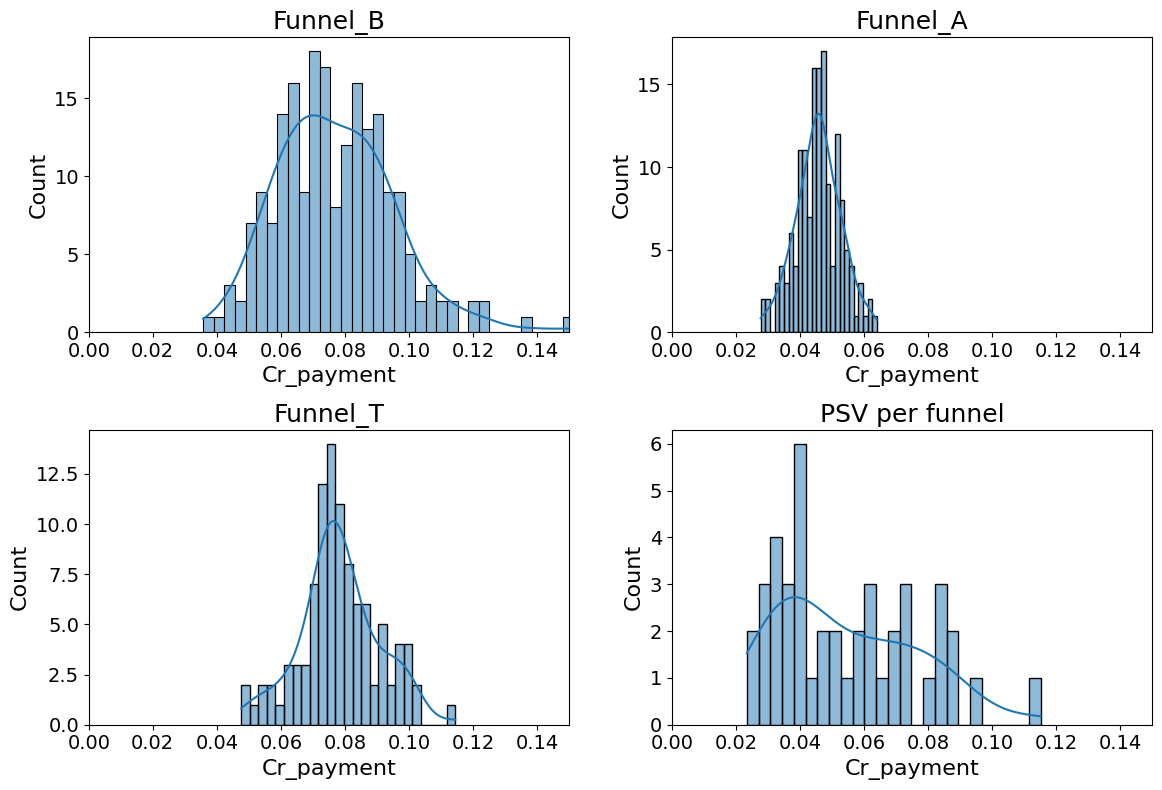

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(beauty_df['Cr_payment'], bins=35, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Funnel_B')
axes[0, 0].set_xlim(0, 0.15)

sns.histplot(ageless_df['Cr_payment'], bins=25, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Funnel_A')
axes[0, 1].set_xlim(0, 0.15)

sns.histplot(tailored_df['Cr_payment'], bins=25, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Funnel_T')
axes[1, 0].set_xlim(0, 0.15)

sns.histplot(quiz_df['Cr_payment'], bins=25, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Funnel_Q')
axes[1, 1].set_xlim(0, 0.15)
plt.title('PSV per funnel')
plt.tight_layout()
plt.show()

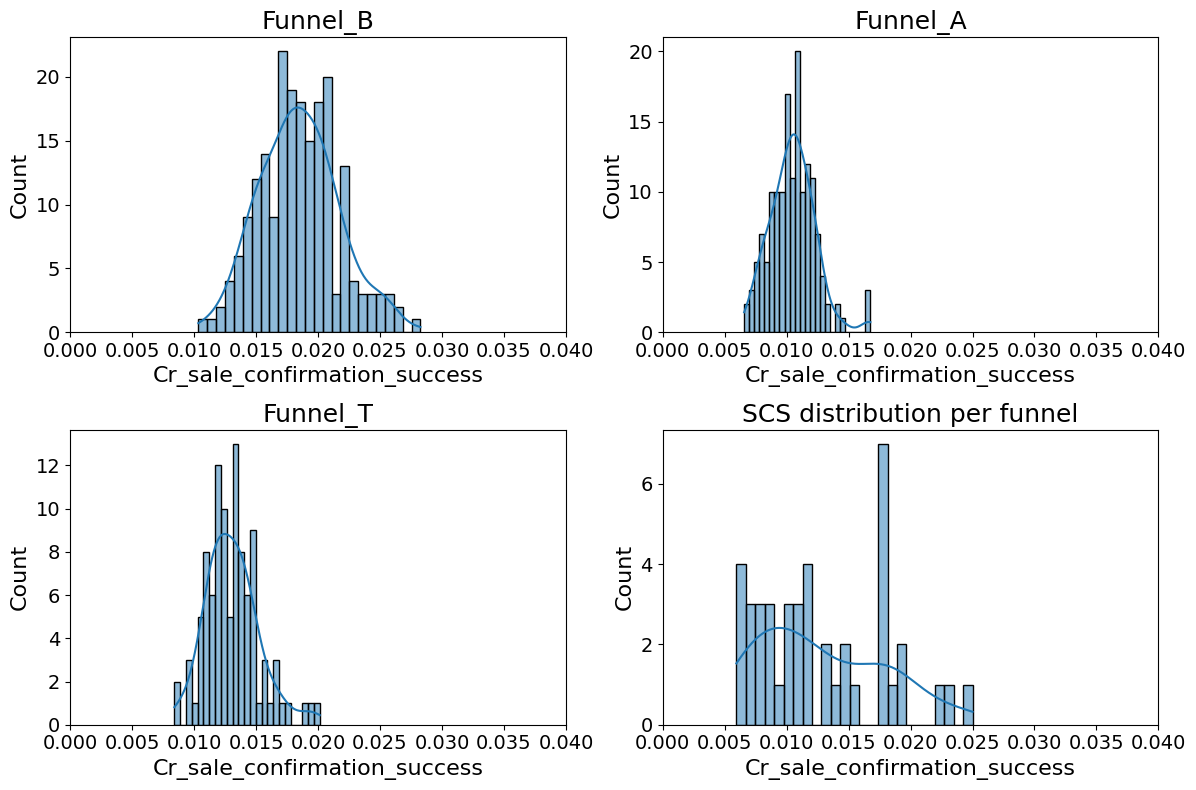

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(beauty_df['Cr_sale_confirmation_success'], bins=25, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Funnel_B')
axes[0, 0].set_xlim(0, 0.04)

sns.histplot(ageless_df['Cr_sale_confirmation_success'], bins=25, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Funnel_A')
axes[0, 1].set_xlim(0, 0.04)

sns.histplot(tailored_df['Cr_sale_confirmation_success'], bins=25, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Funnel_T')
axes[1, 0].set_xlim(0, 0.04)

sns.histplot(quiz_df['Cr_sale_confirmation_success'], bins=25, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Funnel_Q')
axes[1, 1].set_xlim(0, 0.04)
plt.title('SCS distribution per funnel')
plt.tight_layout()
plt.show()

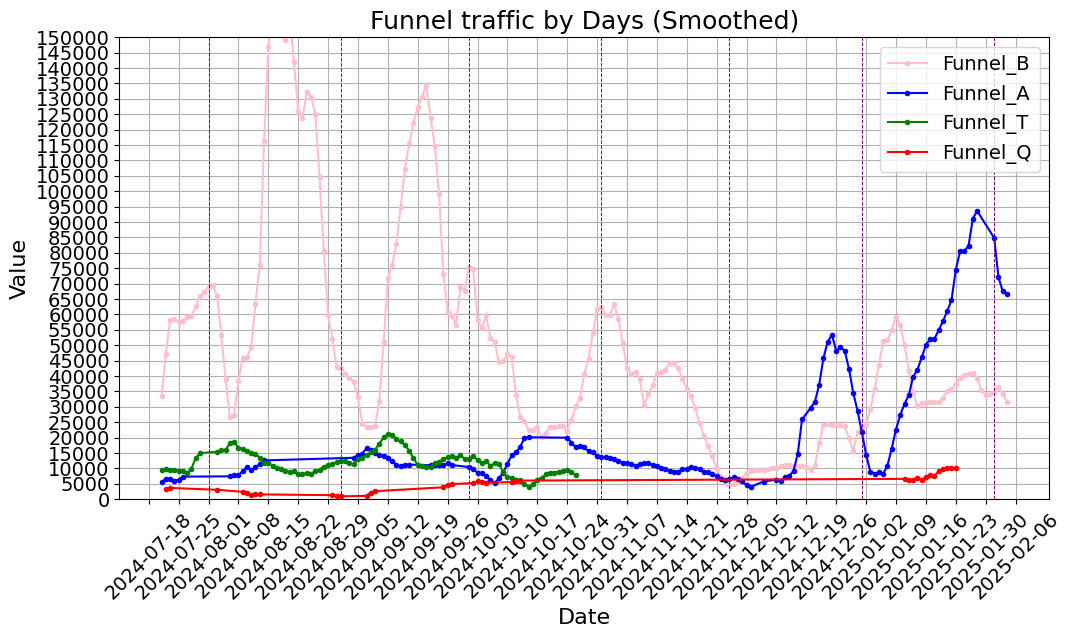

In [93]:

beauty_df['smoothed'] = beauty_df['first_screen_view'].rolling(window=7, center=True).mean()
ageless_df['smoothed'] = ageless_df['first_screen_view'].rolling(window=7, center=True).mean()
tailored_df['smoothed'] = tailored_df['first_screen_view'].rolling(window=7, center=True).mean()
quiz_df['smoothed'] = quiz_df['first_screen_view'].rolling(window=7, center=True).mean()


plt.figure(figsize=(12,6))
plt.plot(beauty_df['yyyymmdd'], beauty_df['smoothed'], marker='.', linestyle='-', color='pink', label="Funnel_B")
plt.plot(ageless_df['yyyymmdd'], ageless_df['smoothed'], marker='.', linestyle='-', color='blue', label="Funnel_A")
plt.plot(tailored_df['yyyymmdd'], tailored_df['smoothed'], marker='.', linestyle='-', color='green', label="Funnel_T")
plt.plot(quiz_df['yyyymmdd'], quiz_df['smoothed'], marker='.', linestyle='-', color='red', label="Funnel_Q")


all_dates = pd.concat([beauty_df['yyyymmdd'], ageless_df['yyyymmdd'], tailored_df['yyyymmdd'], quiz_df['yyyymmdd']])
first_of_months = pd.date_range(start=all_dates.min(), end=all_dates.max(), freq='MS')  # MS = Month Start
for date in first_of_months:
    plt.axvline(x=date, color='purple', linestyle='--', linewidth=0.7)


plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Funnel traffic by Days (Smoothed)")
plt.xticks(beauty_df['yyyymmdd'][::7], rotation=45)
plt.ylim(0, 150000)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5000))

plt.grid(True)
plt.legend()

plt.show()

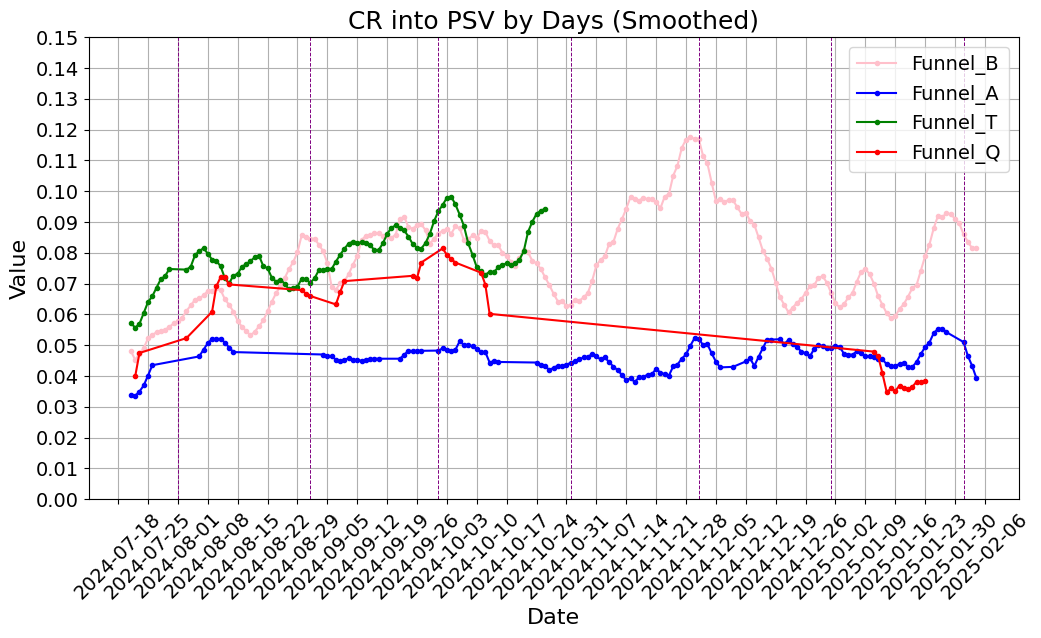

In [94]:

beauty_df['smoothed'] = beauty_df['Cr_payment'].rolling(window=7, center=True).mean()
ageless_df['smoothed'] = ageless_df['Cr_payment'].rolling(window=7, center=True).mean()
tailored_df['smoothed'] = tailored_df['Cr_payment'].rolling(window=7, center=True).mean()
quiz_df['smoothed'] = quiz_df['Cr_payment'].rolling(window=7, center=True).mean()


plt.figure(figsize=(12,6))
plt.plot(beauty_df['yyyymmdd'], beauty_df['smoothed'], marker='.', linestyle='-', color='pink', label="Funnel_B")
plt.plot(ageless_df['yyyymmdd'], ageless_df['smoothed'], marker='.', linestyle='-', color='blue', label="Funnel_A")
plt.plot(tailored_df['yyyymmdd'], tailored_df['smoothed'], marker='.', linestyle='-', color='green', label="Funnel_T")
plt.plot(quiz_df['yyyymmdd'], quiz_df['smoothed'], marker='.', linestyle='-', color='red', label="Funnel_Q")


all_dates = pd.concat([beauty_df['yyyymmdd'], ageless_df['yyyymmdd'], tailored_df['yyyymmdd'], quiz_df['yyyymmdd']])
first_of_months = pd.date_range(start=all_dates.min(), end=all_dates.max(), freq='MS')  # MS = Month Start
for date in first_of_months:
    plt.axvline(x=date, color='purple', linestyle='--', linewidth=0.7)


plt.xlabel("Date")
plt.ylabel("Value")
plt.title("CR into PSV by Days (Smoothed)")
plt.xticks(beauty_df['yyyymmdd'][::7], rotation=45)
plt.ylim(0, 0.15)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.01))

plt.grid(True)
plt.legend()

plt.show()

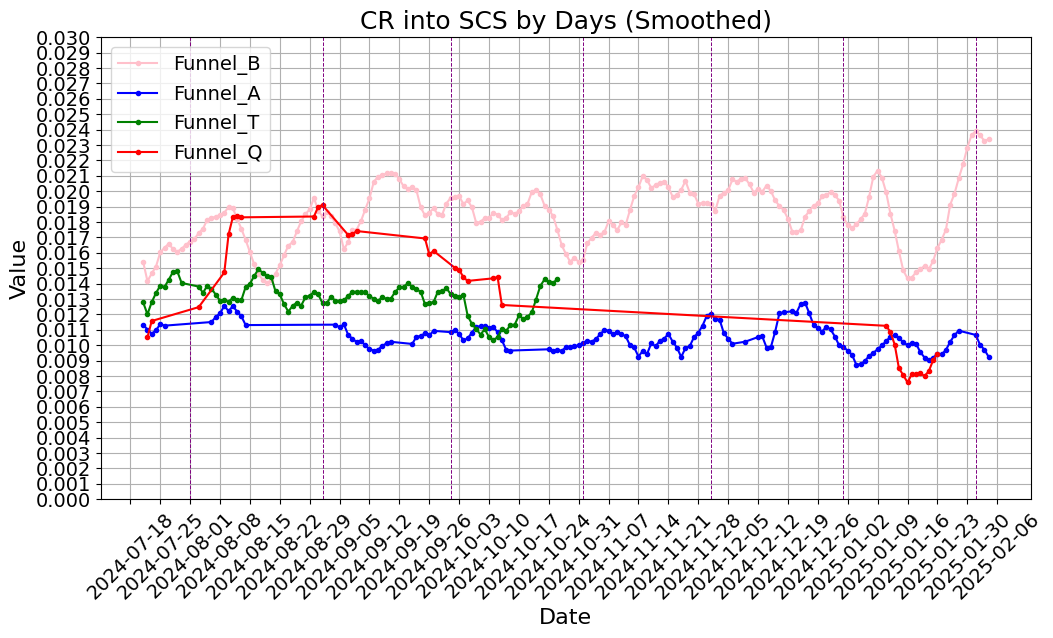

In [95]:
beauty_df['smoothed'] = beauty_df['Cr_sale_confirmation_success'].rolling(window=7, center=True).mean()
ageless_df['smoothed'] = ageless_df['Cr_sale_confirmation_success'].rolling(window=7, center=True).mean()
tailored_df['smoothed'] = tailored_df['Cr_sale_confirmation_success'].rolling(window=7, center=True).mean()
quiz_df['smoothed'] = quiz_df['Cr_sale_confirmation_success'].rolling(window=7, center=True).mean()


plt.figure(figsize=(12,6))
plt.plot(beauty_df['yyyymmdd'], beauty_df['smoothed'], marker='.', linestyle='-', color='pink', label="Funnel_B")
plt.plot(ageless_df['yyyymmdd'], ageless_df['smoothed'], marker='.', linestyle='-', color='blue', label="Funnel_A")
plt.plot(tailored_df['yyyymmdd'], tailored_df['smoothed'], marker='.', linestyle='-', color='green', label="Funnel_T")
plt.plot(quiz_df['yyyymmdd'], quiz_df['smoothed'], marker='.', linestyle='-', color='red', label="Funnel_Q")


all_dates = pd.concat([beauty_df['yyyymmdd'], ageless_df['yyyymmdd'], tailored_df['yyyymmdd'], quiz_df['yyyymmdd']])
first_of_months = pd.date_range(start=all_dates.min(), end=all_dates.max(), freq='MS')  # MS = Month Start
for date in first_of_months:
    plt.axvline(x=date, color='purple', linestyle='--', linewidth=0.7)


plt.xlabel("Date")
plt.ylabel("Value")
plt.title("CR into SCS by Days (Smoothed)")
plt.xticks(beauty_df['yyyymmdd'][::7], rotation=45)
plt.ylim(0, 0.03)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.001))

plt.grid(True)
plt.legend()

plt.show()

In [96]:
beauty_df['smoothed_cr'] = beauty_df['Cr_payment'].rolling(window=28, center=True).mean()
ageless_df['smoothed_cr'] = ageless_df['Cr_payment'].rolling(window=28, center=True).mean()
tailored_df['smoothed_cr'] = tailored_df['Cr_payment'].rolling(window=28, center=True).mean()
quiz_df['smoothed_cr'] = quiz_df['Cr_payment'].rolling(window=28, center=True).mean()
for df in [beauty_df, ageless_df, tailored_df, quiz_df]:
    df['yyyymmdd'] = pd.to_datetime(df['yyyymmdd'])
    df['month'] = df['yyyymmdd'].dt.to_period('M')

monthly_avg_dict = {
    'beauty': round(beauty_df.groupby('month')['smoothed_cr'].mean()).reset_index(),
    'ageless': round(ageless_df.groupby('month')['smoothed_cr'].mean()).reset_index(),
    'tailored': round(tailored_df.groupby('month')['smoothed_cr'].mean()).reset_index(),
    'quiz': round(quiz_df.groupby('month')['smoothed_cr'].mean()).reset_index()
}

# Bayesian models

In [97]:
df_forpriors = final_grouped_df[final_grouped_df["variation"] == "C"].copy()
df_forpriors["prev_cr"] = df_forpriors.groupby("funnel")["conversion_rate"].shift(1)
prev_cr_dict = df_forpriors.set_index("experiment_id")["prev_cr"].dropna().to_dict()


In [98]:

def calculate_metrics_power(experiment_results_dct, simulations=500):
  """
  Calculates simulated conversion rate metrics and relative differences 
  for a set of A/B test results using simulations.

  Args:
      experiment_results_dct (dict): Dictionary with experiment IDs as keys and 
          each value containing 'C_users', 'C_conversions', 'T_users', 'T_conversions'.
      simulations (int): Number of simulations to run for each experiment.

  Returns:
      dict: A dictionary with experiment IDs as keys and calculated metrics 
            (CRs, relative diff, simulated data, etc.) as values.
  """
  simulated_exps = {}
  for test in experiment_results_dct.keys():

    control_start_sample = experiment_results_dct[test]["C_users"]
    control_finish_sample = experiment_results_dct[test]["C_conversions"]

    test_start_sample = experiment_results_dct[test]["T_users"]
    test_finish_sample = experiment_results_dct[test]["T_conversions"]

    CR_1=control_finish_sample/control_start_sample
    CR_2=test_finish_sample/test_start_sample

    if test not in simulated_exps:
      simulated_exps[test] = {}
    simulated_exps[test] ={}
    if control_start_sample == 0 or test_start_sample == 0:
      simulated_exps[test]["Bayes"] = None
      simulated_exps[test]["Simulation_data"] = None
      continue
    simulated_exps[test]["CR_1"] = CR_1
    simulated_exps[test]["CR_2"] = CR_2
    simlation_cr_data= simulate_cr(control_finish_sample, control_start_sample, test_finish_sample, test_start_sample, simulations)
    simulated_exps[test]["diff"] = CR_2/CR_1-1
    simulated_exps[test]["Days"] = final_grouped_df[final_grouped_df['experiment_id'] == test]['test_duration'].iloc[0]
    simulated_exps[test]["Simulation_data"] = simlation_cr_data
  return simulated_exps




In [99]:

def simulate_bayes_loss(simulated_exps,experiment_results_dct, prior_alpha, prior_beta, mde):
  """
Simulates Bayesian stopping for experiments using fixed Beta priors and Monte Carlo simulations.

Args:
    simulated_exps (dict): Simulated experiment results.
    experiment_results_dct (dict): Metadata for real experiments.
    prior_alpha (float): Alpha parameter of Beta prior.
    prior_beta (float): Beta parameter of Beta prior.
    mde (float): Minimum detectable effect size.

Returns:
    merged_experiments_stats (dict): Summary stats per experiment (e.g., CR, p-value, ECDFs).
    extended_sim_stats (dict): Detailed simulation data per experiment.
"""
  merged_experiments_stats ={}
  extended_sim_stats = {}
  for experiment_id, result_dict in tqdm(simulated_exps.items(), desc="loss for experiments"):
      name_entities = experiment_id.split("_")
      date = pd.to_datetime(f"{name_entities[0]}_{name_entities[1]}", format='%Y_%m').strftime('%Y-%m')

      if not experiment_id in merged_experiments_stats:
        merged_experiments_stats[experiment_id] ={}
        extended_sim_stats[experiment_id] = {}

      experiment_row = final_grouped_df[final_grouped_df["experiment_id"] == experiment_id]

      if experiment_id in multivariable_tests_map:
        experiment_t_row = final_grouped_df[(final_grouped_df["experiment_id"] == experiment_id) &
                                (final_grouped_df["variation"] == multivariable_tests_map[experiment_id])]

      else:
        experiment_t_row = final_grouped_df[(final_grouped_df["experiment_id"] == experiment_id) &
                                ((final_grouped_df["variation"] == "T")|(final_grouped_df["variation"] == "T1"))]

      merged_experiments_stats[experiment_id].update({
        "Result_prev": experiment_results_dct[experiment_id]["Result_prev"],
        "CR_1": experiment_t_row["conversion_rate"].iloc[0],
        "Owner": experiment_results_dct[experiment_id]["Owner"],
        "funnel": experiment_row["funnel"].iloc[0],
        "p-value": experiment_results_dct[experiment_id]["Result_our"]["p"],
        "real_sample": experiment_results_dct[experiment_id]["real_sample"],
        "Significant": experiment_results_dct[experiment_id]["Significant"]
    })
      extended_sim_stats[experiment_id] = {}
      extended_sim_stats[experiment_id]["simulation_data"] = {}
      df = result_dict['Simulation_data'].copy()
      df = get_loss(df, 10000, prior_alpha, prior_beta)
      sims = df.copy()
      df['variant'] = 'A'
      df['loss'] = df['loss_a']
      df['cvr'] = df['a_conv'] / df['checkin']

      df1 = df.copy()
      df1['variant'] = 'B'
      df1['loss'] = df1['loss_b']
      df1['cvr'] = df1['b_conv'] / df1['checkin']
      df = pd.concat([df, df1], ignore_index=True)

      threshold = df[df["variant"]=="A"]["cvr"].mean() * mde
      final_checkin = df['checkin'].max()
      outcomes = sims.copy()

      outcomes['threshold_met'] = (outcomes['loss_a'] < threshold) | (outcomes['loss_b'] < threshold)
      outcomes = outcomes[(outcomes['threshold_met']) | (outcomes['checkin'] == final_checkin)]
      outcomes = outcomes.groupby('n_sim').apply(lambda g: g[g['checkin'] == g['checkin'].min()])
      outcomes['selection'] = outcomes.apply(lambda row: 'A' if row['loss_a'] < row['loss_b'] else 'B', axis=1)

      variant_counts = outcomes['selection'].value_counts(normalize=True).reset_index()
      variant_counts.columns = ['variant', 'frequency']

      variant_a_row = variant_counts[variant_counts["variant"]=="A"]
      variant_b_row = variant_counts[variant_counts["variant"]=="B"]

      variant_a_freq = variant_a_row["frequency"].iloc[0] if not variant_a_row.empty else 0
      variant_b_freq = variant_b_row["frequency"].iloc[0] if not variant_b_row.empty else 0
      ecdf_data = outcomes['checkin'] * 2
      extended_sim_stats[experiment_id]["simulation_data"].update({"cvr":df["cvr"],\
                                                        "loss":df["loss"],\
                                                        "checkin":df["checkin"]})
      merged_experiments_stats[experiment_id].update({"ecdf":ecdf_data.quantile([0.80, 0.90, 0.95]), \
                                                                    "variant_A": variant_a_freq ,\
                                                                    "variant_B":variant_b_freq
                                                                    })
  return merged_experiments_stats, extended_sim_stats


In [100]:

def simulate_bayes_loss_prv_cr_diff(simulated_exps,experiment_results_dct, mde, type_prior):
  """
  Runs Bayesian loss-based stopping simulations using priors derived from previous 
  conversion rates and calculates variant selection probabilities.

  Args:
      simulated_exps (dict): Simulated conversion data per experiment.
      experiment_results_dct (dict): Metadata and prior results for experiments.
      mde (float): Minimum detectable effect size as a proportion.
      type_prior (str): Type of prior to use ("weak", "mid", or "strong").

  Returns:
      tuple:
          - merged_experiments_stats (dict): Summary metrics including CRs, p-values, and ECDFs.
          - extended_sim_stats (dict): Detailed simulation results including loss and CVR trajectories.
  """
  merged_experiments_stats ={}
  extended_sim_stats = {}
  for experiment_id, result_dict in tqdm(simulated_exps.items(), desc="loss for experiments"):
      name_entities = experiment_id.split("_")
      date = pd.to_datetime(f"{name_entities[0]}_{name_entities[1]}", format='%Y_%m').strftime('%Y-%m')

      if not experiment_id in merged_experiments_stats:
        merged_experiments_stats[experiment_id] ={}
        extended_sim_stats[experiment_id] = {}

      experiment_row = final_grouped_df[final_grouped_df["experiment_id"] == experiment_id]

      if experiment_id in multivariable_tests_map:
        experiment_t_row = final_grouped_df[(final_grouped_df["experiment_id"] == experiment_id) &
                                (final_grouped_df["variation"] == multivariable_tests_map[experiment_id])]

      else:
        experiment_t_row = final_grouped_df[(final_grouped_df["experiment_id"] == experiment_id) &
                                ((final_grouped_df["variation"] == "T")|(final_grouped_df["variation"] == "T1"))]
      if experiment_id in prev_cr_dict.keys():
        cr = prev_cr_dict[experiment_id]
      else:
        cr = experiment_results_dct_psv[experiment_id]["CR_1"]

      if type_prior == "mid":
        beta_dist = [round(cr, 4)*50000 + 1, 50000 + 1 - round(cr, 4)*50000]

      elif type_prior == "weak":
        beta_dist = [round(cr, 4)*20000 + 1, 20000 + 1 - round(cr, 4)*20000]
      else:
        beta_dist = [round(cr, 4)*100000 + 1, 100000 + 1 - round(cr, 4)*100000]
      prior_alpha, prior_beta = beta_dist[0], beta_dist[1]

      merged_experiments_stats[experiment_id].update({
        "Result_prev": experiment_results_dct[experiment_id]["Result_prev"],
        "CR_1": experiment_t_row["conversion_rate"].iloc[0],
        "Owner": experiment_results_dct[experiment_id]["Owner"],
        "funnel": experiment_row["funnel"].iloc[0],
        "p-value": experiment_results_dct[experiment_id]["Result_our"]["p"],
        "real_sample": experiment_results_dct[experiment_id]["real_sample"],
        "Significant": experiment_results_dct[experiment_id]["Significant"]
    })
      extended_sim_stats[experiment_id] = {}
      extended_sim_stats[experiment_id]["simulation_data"] = {}
      df = result_dict['Simulation_data'].copy()
      df = get_loss(df, 10000, prior_alpha, prior_beta)
      sims = df.copy()
      df['variant'] = 'A'
      df['loss'] = df['loss_a']
      df['cvr'] = df['a_conv'] / df['checkin']

      df1 = df.copy()
      df1['variant'] = 'B'
      df1['loss'] = df1['loss_b']
      df1['cvr'] = df1['b_conv'] / df1['checkin']
      df = pd.concat([df, df1], ignore_index=True)

      threshold = df[df["variant"]=="A"]["cvr"].mean() * mde
      final_checkin = df['checkin'].max()
      outcomes = sims.copy()

      outcomes['threshold_met'] = (outcomes['loss_a'] < threshold) | (outcomes['loss_b'] < threshold)
      outcomes = outcomes[(outcomes['threshold_met']) | (outcomes['checkin'] == final_checkin)]
      outcomes = outcomes.groupby('n_sim').apply(lambda g: g[g['checkin'] == g['checkin'].min()])
      outcomes['selection'] = outcomes.apply(lambda row: 'A' if row['loss_a'] < row['loss_b'] else 'B', axis=1)

      variant_counts = outcomes['selection'].value_counts(normalize=True).reset_index()
      variant_counts.columns = ['variant', 'frequency']

      variant_a_row = variant_counts[variant_counts["variant"]=="A"]
      variant_b_row = variant_counts[variant_counts["variant"]=="B"]

      variant_a_freq = variant_a_row["frequency"].iloc[0] if not variant_a_row.empty else 0
      variant_b_freq = variant_b_row["frequency"].iloc[0] if not variant_b_row.empty else 0
      ecdf_data = outcomes['checkin'] * 2
      extended_sim_stats[experiment_id]["simulation_data"].update({"cvr":df["cvr"],\
                                                        "loss":df["loss"],\
                                                        "checkin":df["checkin"]})
      merged_experiments_stats[experiment_id].update({"ecdf":ecdf_data.quantile([0.80, 0.90, 0.95]), \
                                                                    "variant_A": variant_a_freq ,\
                                                                    "variant_B":variant_b_freq
                                                                    })
  return merged_experiments_stats, extended_sim_stats


In [101]:

def group_datasets(merged_experiments_stats):
  """
  Groups experiments by 'Result_prev' into predefined categories.
  """
  grouped_by_result = {
      'Control': {},
      'Test': {},
      'No Stat Diff': {},
      'Inconclusive':{}
  }


  for exp_id, details in merged_experiments_stats.items():
      result = details.get('Result_prev')
      if result in grouped_by_result:
          grouped_by_result[result].update({exp_id:merged_experiments_stats[exp_id]})
      else:
          grouped_by_result['Inconclusive'].update(exp_id)
  return grouped_by_result


In [102]:
def create_results(df_simulations,filter_col, result_col ):
  """
  Extracts a summary DataFrame from simulations, selecting 'ecdf_80' or 'P_B_better' per experiment.
  """
  rows = []
  avoid = []
  for exp_id, exp_data in df_simulations[filter_col].items():
      row = {
          'experiment': exp_id,
          'Result_prev': exp_data['Result_prev'],
          'real_sample': exp_data['real_sample'],
          'Significant': exp_data['Significant']
      }

      if result_col == "ecdf":
        value = exp_data[result_col].get(0.80, np.nan)
        row[f'ecdf_80'] = int(value)
      else:
        value = exp_data[result_col]
        row[f'P_B_better'] = float(value)
      rows.append(row)

  df = pd.DataFrame(rows).set_index('experiment')
  return df


In [103]:

combination_filter = ["Test", "Control", "No Stat Diff"]

def aggregate_results(df_simulations, combination_filter, result_col):
  """
  Aggregate average results by group (Test, Control, No Stat Diff).
  """
  aggregated_rows = []
  df1 = pd.DataFrame()
  for filter_col in combination_filter:
      df_result = create_results(df_simulations, filter_col, result_col)
      average_row = df_result.select_dtypes(include=[np.number]).mean(numeric_only=True)
      average_row_formatted = average_row.apply(lambda x: f"{round(float(x),2):,}" if pd.notna(x) else "")
      average_df = pd.DataFrame(average_row_formatted).T
      average_df.index = [f"{filter_col}"]
      aggregated_rows.append(average_df)

  final_df = pd.concat(aggregated_rows)

  return final_df


In [104]:

def show_detailed_exp_results(grouped_by_result, filter_column, result_column):
  """
  Create a table with day-by-day experiment results for a specific group.
  """
  rows = []
  for exp_id, exp_data in grouped_by_result[filter_column].items():
      row = {
          'experiment': exp_id,
          'Result_prev': exp_data['Result_prev'],
          'real_sample': exp_data['real_sample'],
          'Significant': exp_data['Significant']
      }
      for i, day in enumerate(exp_data['days'].keys(), start=1):
          if i > 8:
              break
          day_data = exp_data['days'][day]
          value = day_data[result_column]
          row[f'day_{day}_Prob_B_better'] = value
      rows.append(row)

  df = pd.DataFrame(rows).set_index('experiment')
  return df

## Stacked solution

In [105]:

def get_bayes_results(experiment_results_dct,simulated_exps, prior_alpha, prior_beta,mde):
    """
    Run Bayesian simulations, group experiments by outcome, and aggregate ECDF and variant B probabilities.
    """
    merged_experiments_stats, extended_sim_stats = simulate_bayes_loss(simulated_exps,experiment_results_dct, prior_alpha, prior_beta,mde)

    grouped_by_result = group_datasets(merged_experiments_stats)

    aggregated_results_ecdf = aggregate_results(grouped_by_result, combination_filter, "ecdf")
    aggregated_results_pB = aggregate_results(grouped_by_result, combination_filter, "variant_B")
    return aggregated_results_ecdf,aggregated_results_pB, grouped_by_result, merged_experiments_stats,extended_sim_stats


In [106]:

def get_bayes_results_cr_prev(experiment_results_dct,simulated_exps, type_prior):
    """
    Run Bayesian simulations, group experiments by outcome, and aggregate ECDF and variant B probabilities.
    """
    merged_experiments_stats, extended_sim_stats = simulate_bayes_loss_prv_cr_diff(simulated_exps,experiment_results_dct,0.004,type_prior)

    grouped_by_result = group_datasets(merged_experiments_stats)

    aggregated_results_ecdf = aggregate_results(grouped_by_result, combination_filter, "ecdf")
    aggregated_results_pB = aggregate_results(grouped_by_result, combination_filter, "variant_B")
    return aggregated_results_ecdf,aggregated_results_pB, grouped_by_result, merged_experiments_stats,extended_sim_stats


# Priors estimation


In [107]:
cr_basic = distribution_df["Cr_payment"].mean()
funnels_cr_df = distribution_df.groupby("siteDomain")["Cr_payment"].mean()

funnel_A_cr = funnels_cr_df["Funnel_A"]
funnel_B_cr = funnels_cr_df["Funnel_B"]
funnel_Q_cr = funnels_cr_df["Funnel_Q"]
funnel_T_cr = funnels_cr_df["Funnel_T"]

## fit priors

### functions-helpers

In [108]:
real_crs_basic = [exp["conversion_rate"] for exp in experiment_results_dct_psv.values() if exp.get("conversion_rate") is not None]

def get_mean_var_from_cr(distribution_df, funnel):
  """
  Calculate mean and variance of conversion rates for a given funnel.
  """
  real_crs = distribution_df[distribution_df['siteDomain']==funnel]["Cr_payment"]
  observed_mean = np.mean(real_crs)
  observed_var = np.var(real_crs)
  return observed_mean,observed_var


In [109]:
def beta_variance(alpha, beta_):
    return (alpha * beta_) / ((alpha + beta_)**2 * (alpha + beta_ + 1))

In [110]:
def create_dynamic_priors(cr, observed_variance, mid_total_weight=5000, strong_total_weight=10000):
    """
    Generate weak, mid, and strong Beta priors based on conversion rate and total weights.
    """
    mid_alpha = cr * mid_total_weight
    mid_beta = (1 - cr) * mid_total_weight

    strong_alpha = cr * strong_total_weight
    strong_beta = (1 - cr) * strong_total_weight

    return {"weak":[1,1],
        "mid": [round(mid_alpha), round(mid_beta)],
        "strong": [round(strong_alpha), round(strong_beta)]
    }

priors = create_dynamic_priors(np.mean(real_crs_basic), np.var(real_crs_basic))


In [111]:

def simulate_with_priors(basic_priors_dct, experiment_results_dct_psv,simulated_exps, path):
  """
  Run Bayesian simulations across different priors and save the results to a file.
  """
  results_basic_priors={}
  for key,pair in basic_priors_dct.items():
    print(key)
    alpha, beta = pair[0], pair[1]
    aggregated_results_ecdf,aggregated_results_pB, grouped_by_result, merged_experiments_stats,extended_sim_stats  = get_bayes_results(experiment_results_dct_psv,simulated_exps, alpha, beta,0.003)
    results_basic_priors[key] = {}
    results_basic_priors[key]["all"] = {"ecdf":aggregated_results_ecdf, "pB":aggregated_results_pB, "other":[grouped_by_result, merged_experiments_stats,extended_sim_stats]}

  with open(path, "wb") as f:
    pickle.dump(results_basic_priors, f)

  print(f"Saved simulation results to: {os.path.abspath(path)}")
  return results_basic_priors


In [112]:
def get_funnel_value(v):
    f = v.get("funnel")
    if isinstance(f, pd.Series):
        return f.iloc[0] if not f.empty else None
    return f

def return_all_result_dict_for_funnels(experiment_results_dct_psv,experiment_results_dct_psv_sign,experiment_results_dct_psv_mixed, funnel):
    experiment_results_dct_psv_funnelA = {
        k: v for k, v in experiment_results_dct_psv.items()
        if get_funnel_value(v) == funnel
    }
    experiment_results_dct_psv_sign_funnelA = {
        k: v for k, v in experiment_results_dct_psv_sign.items()
        if get_funnel_value(v) == funnel
    }
    experiment_results_dct_psv_mixed_funnelA = {
        k: v for k, v in experiment_results_dct_psv_mixed.items()
        if get_funnel_value(v) == funnel
    }
    names = {
        k for k, v in experiment_results_dct_psv.items()
        if get_funnel_value(v) == funnel
    }
    return experiment_results_dct_psv_funnelA,experiment_results_dct_psv_sign_funnelA,experiment_results_dct_psv_mixed_funnelA,names

### Simulation preparation. Prepare specific dataframes for FunnelA & B + create basic priors for each funnel

In [113]:
real_crs_funnelA, varA = get_mean_var_from_cr(distribution_df, "Funnel_A")
real_crs_funnelB, varB = get_mean_var_from_cr(distribution_df, "Funnel_B")
real_crs_funnelT, varT = get_mean_var_from_cr(distribution_df, "Funnel_T")
real_crs_funnelQ, varQ = get_mean_var_from_cr(distribution_df, "Funnel_Q")

basic_priors_dct = create_dynamic_priors(np.mean(real_crs_basic), np.var(real_crs_basic))
funnelA_priors_dct = create_dynamic_priors(real_crs_funnelA, varA)
funnelB_priors_dct = create_dynamic_priors(real_crs_funnelA,varB)
funnelT_priors_dct = create_dynamic_priors(real_crs_funnelA, varT)
funnelQ_priors_dct = create_dynamic_priors(real_crs_funnelA, varQ)

In [114]:
experiment_results_dct_psv_funnelA,experiment_results_dct_psv_sign_funnelA,experiment_results_dct_psv_mixed_funnelA,names = return_all_result_dict_for_funnels(experiment_results_dct_psv,experiment_results_dct_psv_sign,experiment_results_dct_psv_mixed, "Funnel_A")

experiment_results_dct_psv_funnelB,experiment_results_dct_psv_sign_funnelB,experiment_results_dct_psv_mixed_funnelB,namesB = return_all_result_dict_for_funnels(experiment_results_dct_psv,experiment_results_dct_psv_sign,experiment_results_dct_psv_mixed, "Funnel_B")

# Simulate experiments or load them

In [ ]:
simulated_exps = calculate_metrics_power(experiment_results_dct_psv)
simulated_exps_sign = calculate_metrics_power(experiment_results_dct_psv_sign)
simulated_exps_mixed = calculate_metrics_power(experiment_results_dct_psv_mixed)


In [116]:


def save_simulated_exps_to_pickle(simulated_exps, filename):
    with open(filename, "wb") as f:
        pickle.dump(simulated_exps, f)


save_simulated_exps_to_pickle(simulated_exps, "results_data/simulated_exps_new.pkl")
save_simulated_exps_to_pickle(simulated_exps_sign, "results_data/simulated_exps_sign_new.pkl")
save_simulated_exps_to_pickle(simulated_exps_mixed, "results_data/simulated_exps_mixed_new.pkl")

In [117]:

def load_simulated_exps_from_pickle(filename):
    """
    Load simulated experiments from a pickle file.
    """
    with open(filename, "rb") as f:
        return pickle.load(f)

simulated_exps = load_simulated_exps_from_pickle("results_data/simulated_exps_new.pkl")
simulated_exps_sign = load_simulated_exps_from_pickle("results_data/simulated_exps_sign_new.pkl")
simulated_exps_mixed = load_simulated_exps_from_pickle("results_data/simulated_exps_mixed_new.pkl")

In [118]:
def filter_sims(names):
  filtered_simulated_exps = {
      k: v for k, v in simulated_exps.items() if k in names
  }
  filtered_simulated_exps_sign= {
      k: v for k, v in simulated_exps_sign.items() if k in names
  }
  return filtered_simulated_exps,filtered_simulated_exps_sign


In [119]:
filtered_simulated_expsA,filtered_simulated_exps_signA = filter_sims(names)
filtered_simulated_expsB,filtered_simulated_exps_signB = filter_sims(namesB)

# Plot experiment simulations

In [120]:
def plot_experiment_simulation(result_dict, mde, prior_alpha, prior_beta):
    """
    result_dict: one entry from simulated_exps, e.g.
                 simulated_exps['2024_10_14_experiment_21']
    mde:        minimum detectable effect, e.g. 0.10 for 10%
    prior_alpha, prior_beta: parameters for your Beta prior in get_loss()
    """

    df = result_dict['Simulation_data'].copy()

    df = get_loss(df, 10000, prior_alpha, prior_beta)

    df_a = df.assign(variant='A', loss=df.loss_a, cvr=df.a_conv / df.checkin)
    df_b = df.assign(variant='B', loss=df.loss_b, cvr=df.b_conv / df.checkin)
    df_plot = pd.concat([df_a, df_b], ignore_index=True)

    sims = df.copy()
    sims['threshold_met'] = (sims.loss_a < (df_plot.query("variant=='A'")['cvr'].mean() * mde)) \
                          | (sims.loss_b < (df_plot.query("variant=='A'")['cvr'].mean() * mde))
    final_checkin = sims['checkin'].max()
    outcomes = (sims[sims.threshold_met | (sims.checkin == final_checkin)]
                .groupby('n_sim', group_keys=False)
                .apply(lambda g: g.loc[g.checkin.idxmin()]))
    outcomes['selection'] = outcomes.apply(
        lambda r: 'A' if r.loss_a < r.loss_b else 'B', axis=1
    )

    threshold = df_plot.query("variant=='A'")['cvr'].mean() * mde

    plt.figure(figsize=(10,5))
    sns.lineplot(data=df_plot, x='checkin', y='cvr', hue='variant')
    plt.title("Observed conversion rate by variant")
    plt.xlabel("Observations per variant")
    plt.ylabel("Conversion rate")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,5))
    sns.lineplot(data=df_plot, x='checkin', y='loss', hue='variant')
    plt.axhline(threshold, linestyle='--', color='gray',
                label=f"Threshold = {threshold:.5f}")
    plt.title("Expected loss by variant")
    plt.xlabel("Observations per variant")
    plt.ylabel("Expected loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    sns.ecdfplot(outcomes['checkin'] * 2)
    plt.title("eCDF of experiment duration")
    plt.xlabel("Total observations (A+B) at stop")
    plt.ylabel("Fraction of sims stopped")
    plt.grid(True)
    plt.show()

    freq = outcomes.selection.value_counts(normalize=True) \
                    .rename_axis('variant') \
                    .reset_index(name='frequency')
    plt.figure(figsize=(6,5))
    sns.barplot(data=freq, x='variant', y='frequency', palette='pastel')
    for i, row in freq.iterrows():
        plt.text(i, row.frequency + 0.01, f"{row.frequency:.2f}", ha='center')
    plt.title("Fraction of sims choosing each variant")
    plt.ylim(0,1)
    plt.grid(axis='y')
    plt.show()

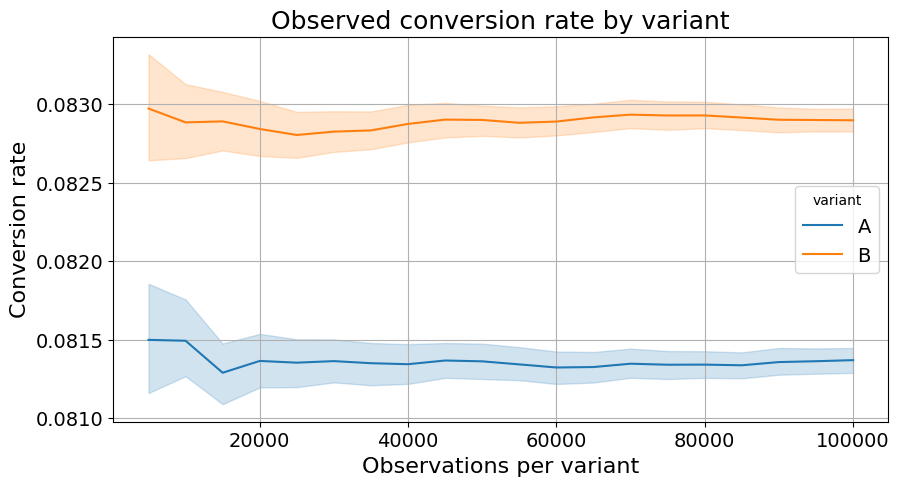

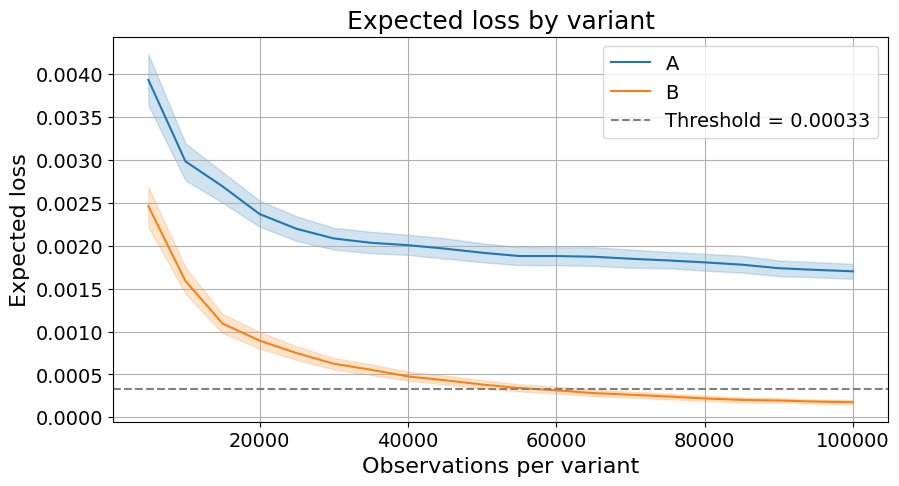

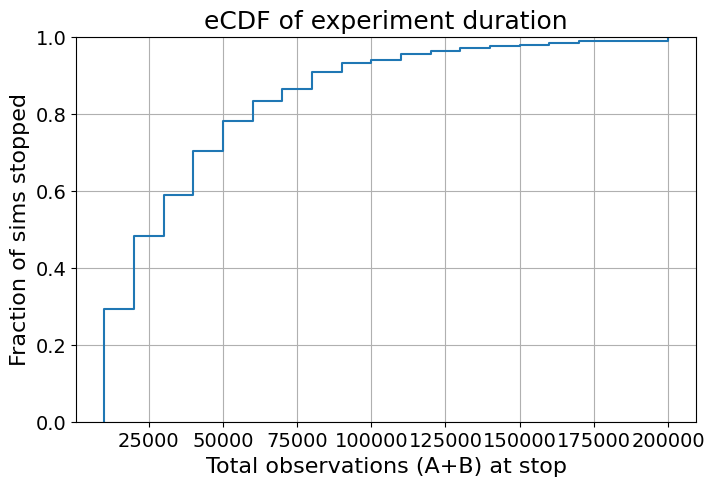

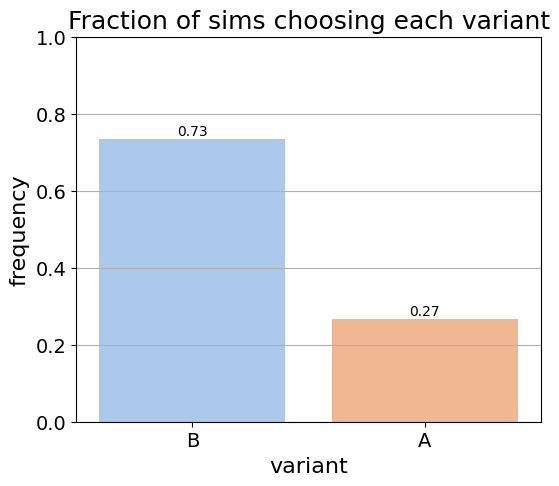

In [121]:
exp_id = '2024_08_03_experiment_5'
plot_experiment_simulation(
    simulated_exps[exp_id],
    mde=0.004,
    prior_alpha=1,
    prior_beta=1
)

## basic priors results (average cr for all funnels combined)

# Results

## Threshold change impact on basic priors results(0.003 instead of 0.004)

In [122]:
def load_simulation_results(path):
    with open(path, "rb") as f:
        results_basic_priors = pickle.load(f)
    return results_basic_priors

In [ ]:
funnel_priors_results = simulate_with_priors(basic_priors_dct, experiment_results_dct_psv,simulated_exps,"results_data/basic_priors_results.pkl")


In [ ]:
funnel_priors_results_threshold2 = simulate_with_priors(basic_priors_dct, experiment_results_dct_psv,simulated_exps,"results_data/basic_priors_results_tres.pkl")


by changing "strong" parameter to "weak" or "mid", you get a different estimation of sample size.

In [ ]:
aggregated_results_ecdf1,aggregated_results_pB1, grouped_by_result1, merged_experiments_stats1,extended_sim_stats1 = get_bayes_results_cr_prev(experiment_results_dct_psv,simulated_exps, "strong")

In [ ]:
funnelA_priors_results = simulate_with_priors(funnelA_priors_dct, experiment_results_dct_psv_funnelA,filtered_simulated_expsA,"results_data/funnelA_priors_results.pkl")
funnelB_priors_results = simulate_with_priors(funnelB_priors_dct, experiment_results_dct_psv_funnelB,filtered_simulated_expsB,"results_data/funnelB_priors_results.pkl")


## For your comfort, you can download all results

In [124]:
funnel_priors_results = load_simulation_results("results_data/basic_priors_results.pkl")
funnel_priors_results_threshold2 = load_simulation_results("results_data/basic_priors_results_tres.pkl")
funnelA_priors_results = load_simulation_results("results_data/basicA_priors_results.pkl")
funnelB_priors_results = load_simulation_results("results_data/basicB_priors_results.pkl")

## How to interpret results

- parameter `strong`/`mid`/`weak` represents the strengths of a prior
- parameter `all` represents all tests(for only significant you can visit get_detailed_significant_dataset_stats(grouped_by_result) function)
- parameter `ecdf`/`pB` represents stats results: 
    - `ecdf` shows the average sample size for TWO groups combined
    - `pB` shows the percent of time that test gwoup was chosen as a winner

IMPORTANT! column `real_sample` shows real sample size, gathered for ONE group. To compare it with column `ecdf`, multiply it by 2.

### results for basic average cr of all funnels

In [125]:
funnel_priors_results["strong"]["all"]["ecdf"]

,real_sample,ecdf_80
Test,"48,366.96","66,666.67"
Control,"17,784.08","43,076.92"
No Stat Diff,"33,430.75","68,750.0"


In [ ]:
funnel_priors_results["strong"]["all"]["pB"]

,real_sample,P_B_better
Test,"48,366.96",0.66
Control,"17,784.08",0.15
No Stat Diff,"33,430.75",0.43


### results with lower threshold

In [ ]:
funnel_priors_results_threshold2["strong"]["all"]["ecdf"]

,real_sample,ecdf_80
Test,"48,366.96","83,833.33"
Control,"17,784.08","50,000.0"
No Stat Diff,"33,430.75","91,375.0"


In [ ]:
funnel_priors_results_threshold2["strong"]["all"]["pB"]

,real_sample,P_B_better
Test,"48,366.96",0.67
Control,"17,784.08",0.15
No Stat Diff,"33,430.75",0.42


In [ ]:
def get_detailed_significant_dataset_stats(grouped_by_result):
    sign_dct = {}

    for group_name, experiments in grouped_by_result1.items():
        filtered_experiments = {}
        for exp_id, exp_data in experiments.items():
            if exp_id in experiment_results_dct_psv_sign.keys():
                filtered_experiments[exp_id] = exp_data
        if filtered_experiments: 
            sign_dct[group_name] = filtered_experiments
    return sign_dct


### results for priors with basic cr of each funnel
To use this function, pass an an argument part of the dictionary

Example:
If you want to get results only from the significant tests with posterior, based on priors of funnel A:
- pass the dataset `funnelA_priors_results`
- pass parameters of specific cohort `weak`, `all`, `other`
- create `sign_dict` and corresponding `aggregated_results_ecdf`, `aggregated_results_pB`


In [ ]:
grouped_by_result = funnelA_priors_results["weak"]["all"]["other"][0]
sign_dct = get_detailed_significant_dataset_stats(grouped_by_result)


In [ ]:
aggregated_results_ecdf = aggregate_results(sign_dct, combination_filter, "ecdf")
aggregated_results_pB = aggregate_results(sign_dct, combination_filter, "variant_B")

plot the result

ATTENTION! Remember, that `real_sample` column has a sample size only for one variation, whereas `ecdf` has for two variations. Multiply `real_sample` *2 to get a full sample for the test

In [ ]:
aggregated_results_ecdf

,real_sample,ecdf_80
Test,"79,895.43","18,571.43"
Control,"23,329.0","18,400.0"
No Stat Diff,"26,086.5","30,000.0"
